# LendingClub Loan Default Risk Analysis

Objective:
The purpose of this analysis is to identify which borrower characteristics are associated with default
risk using historical consumer loan data from LendingClub, a peer-to-peer marketplace that facilitates unsecured personal loans for borrowers and funding from investors. By examining variables such as borrower income, debt-to-income
ratio, loan amount, and interest rate, the analysis seeks to determine which factors are most strongly correlated
with loan repayment outcomes.

Context:
Understanding default risk is a core function of credit analysis within banks and lending institutions. Financial
institutions evaluate borrower characteristics to estimate the probability of repayment and price loans accordingly.

Approach:
This project uses a sample of LendingClub loan data to:
1. Clean and prepare borrower and loan-level data
2. Conduct exploratory data analysis to identify patterns associated with default
3. Visualize relationships between borrower characteristics and loan outcomes
4. Build a simple predictive model (logistic regression) to estimate default probability

Goal:
This project is intended to simulate the type of credit risk analysis performed by financial institutions when evaluating
consumer lending portfolios and assessing borrower risk.

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load LendingClub dataset
# Here we select only the first 50,000 rows from the dataset, since the full dataset contains millions of rows.
# For the purpose of our analysis, this will be plenty of data to work with

df = pd.read_csv("accepted_2007_to_2018Q4.csv", nrows=50000, low_memory=False)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Review dataset structure, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 57.6+ MB


In [4]:
# Inspecting the dataset to see what variables we have
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [5]:
# Review loan outcome categories to assess the overall frequency of repayment vs default
# This helps to establish the baseline default rate across the entire dataset before further analysis
df['loan_status'].value_counts()

loan_status
Fully Paid            34978
Charged Off            9027
Current                5610
Late (31-120 days)      246
In Grace Period         100
Late (16-30 days)        38
Default                   1
Name: count, dtype: int64

In [6]:
# Keep only the completed loans, excluding current loans since we don't yet know their final outcome
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

In [7]:
# Create a binary target variable for default risk modeling
# 1 = Charged Off (default)
# 0 = Fully Paid (successful repayment)
df["default"] = (df["loan_status"] == "Charged Off").astype(int)

In [8]:
# Verify the indicator was created successfully,
# 0 represents repaid loans, 1 represents defaults
df["default"].value_counts()

default
0    34978
1     9027
Name: count, dtype: int64

In [9]:
# Calculate the overall default rate and display it as a percentage
default_rate = df["default"].mean()

print(f"Default Rate: {default_rate:.2%}")

Default Rate: 20.51%


The overall baseline default rate in this sample is approximately 20.51%.
This indicates that roughly one in five loans in the data set resulted in a charge-off.

Next we will begin to **analyze borrower characteristics that may be associated with higher default risk**.

### Borrower Income and Default Risk

In [10]:
# First, we will examine the relationship between borrower income levels and loan default rates
# Presumably, higher borrower income would indicate a greater capacity for repayment

# We'll start by creating borrower income bands to group borrowers by income level
# Binning will reduce the effect of outliers and make interpretation easier
# These brackets roughly represent common borrower income tiers:
# <40k     -> lower income borrowers
# 40-80k   -> lower-middle income
# 80-120k  -> middle income
# 120-200k -> upper-middle income
# 200k+    -> high income borrowers

df['income_band'] = pd.cut(
    df['annual_inc'],
    bins=[0, 40000, 80000, 120000, 200000, 1000000],
    labels=['<40k', '40k-80k', '80k-120k', '120k-200k', '200k+']
)

# Calculate default rates within each income band
income_default = df.groupby('income_band', observed=False)['default'].mean().reset_index()
# Convert default rate into percentage form for readability
income_default['default_pct'] = income_default['default'] * 100

income_default

,income_band,default,default_pct
0,<40k,0.227020,22.702004
1,40k-80k,0.218877,21.887653
2,80k-120k,0.182973,18.297252
3,120k-200k,0.163576,16.357584
4,200k+,0.126449,12.644889


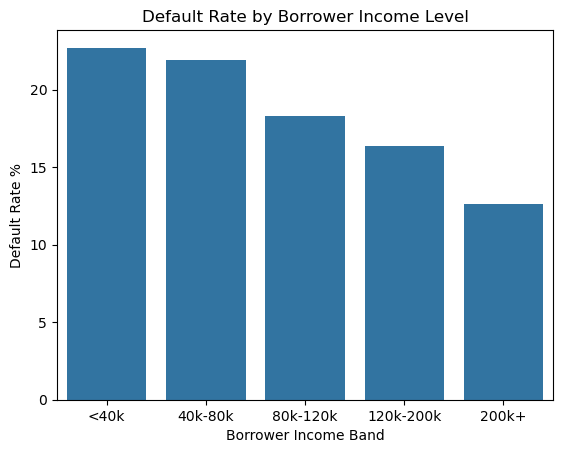

In [11]:
# Now let's visualize how default rates vary across the borrower income tiers
# If borrower income is associated with repayment capacity, we expect to see lower default rates among high income borrowers

sns.barplot(x='income_band', y='default_pct', data=income_default)
plt.title("Default Rate by Borrower Income Level")
plt.xlabel("Borrower Income Band")
plt.ylabel("Default Rate %")

plt.show()

**Key Insight**

As expected, default rates decline as borrower income increases, suggesting that higher-income borrowers generally exhibit stronger repayment capacity. Loans issued to borrowers with annual incomes below $40,000 experience the highest default rates, while borrowers earning above 200,000 display substantially lower default risk. However, income alone does not fully explain default behavior.

### Debt-to-Income Ratio and Default Risk

In [12]:
# Now, we will explore whether borrower's leverage (DTI ratio) is associated with higher default risk
# Beginning with examining the summary statistics of borrower debt-to-income ratios
df["dti"].describe()

count    44004.000000
mean        19.084501
std          9.914473
min          0.000000
25%         12.420000
50%         18.530000
75%         25.310000
max        999.000000
Name: dti, dtype: float64

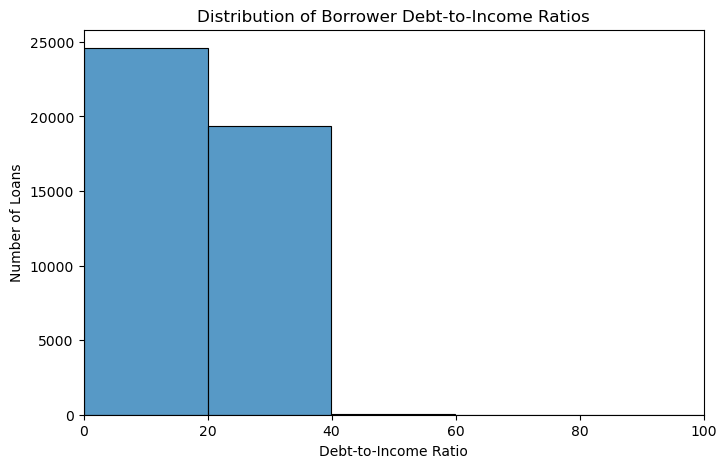

In [13]:
# Next, we will look at how debt-to-income ratios are distributed across borrowers using a visualization
plt.figure(figsize=(8,5))
sns.histplot(df["dti"], bins=50)

plt.title("Distribution of Borrower Debt-to-Income Ratios")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Loans")

plt.xlim(0, 100)


plt.show()

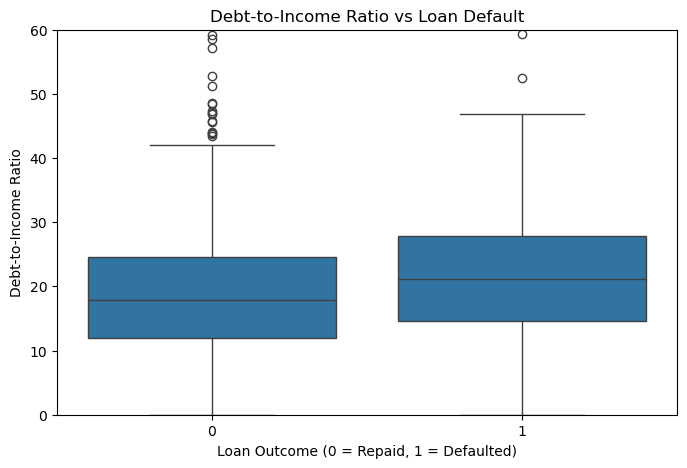

In [14]:
# Now we will compare borrower DTI ratios between repaid and defaulted loans
plt.figure(figsize=(8,5))
sns.boxplot(x="default", y="dti", data=df)

plt.ylim(0, 60)

plt.title("Debt-to-Income Ratio vs Loan Default")
plt.xlabel("Loan Outcome (0 = Repaid, 1 = Defaulted)")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

**Key Insight**

The boxplot above demonstrates that borrowers who defaulted on their loans tend to have higher debt-to-income
ratios than those who successfully repaid their loans. This suggests that borrower leverage may be associated
with increased default risk, which aligns with common credit risk theory.

### Loan Amount vs Default Risk

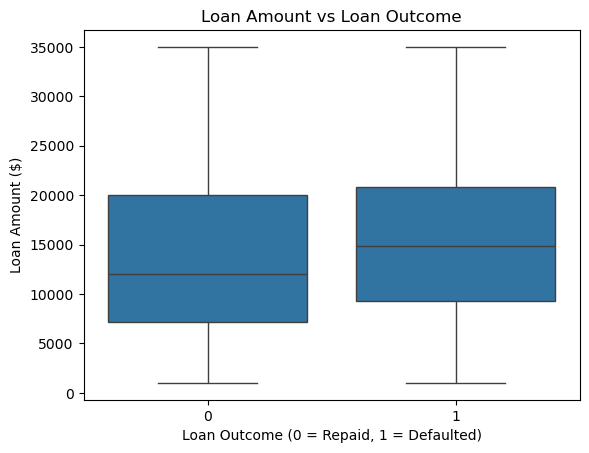

In [15]:
# Now we will examine whether larger loan amounts are associated with higher default risk
# A similar boxplot to the one we used above allows us to compare the distribution of loan amounts between
# loans that were fully repaid and those that defaulted

sns.boxplot(x='default', y='loan_amnt', data=df)
plt.title("Loan Amount vs Loan Outcome")
plt.xlabel("Loan Outcome (0 = Repaid, 1 = Defaulted)")
plt.ylabel("Loan Amount ($)")

plt.show()

**Key Insight**

The distribution of loan amounts appears to be broadly similar between repaid and defaulted loans, suggesting that loan size in and of itself may not be a strong predictor of default risk. However, larger loans may still interact with other borrower characteristics such as income and debt-to-income ratios.

### Loan Grade vs Default Risk

In [16]:
# Next, we will explore default rates across different LendingClub loan grades. LendingClub grades loans on a 
# scale from A, representing lowest risk and lowest interest rates, to G, representing highest risk and higher interest

#calculating the default rate by grade
grade_default = df.groupby('grade')['default'].mean().reset_index()
grade_default['default_pct'] = grade_default['default'] * 100
#display results
grade_default

,grade,default,default_pct
0,A,0.052775,5.277547
1,B,0.137931,13.793103
2,C,0.235010,23.501022
3,D,0.352341,35.234073
4,E,0.449333,44.933285
5,F,0.527711,52.771084
6,G,0.565445,56.544503


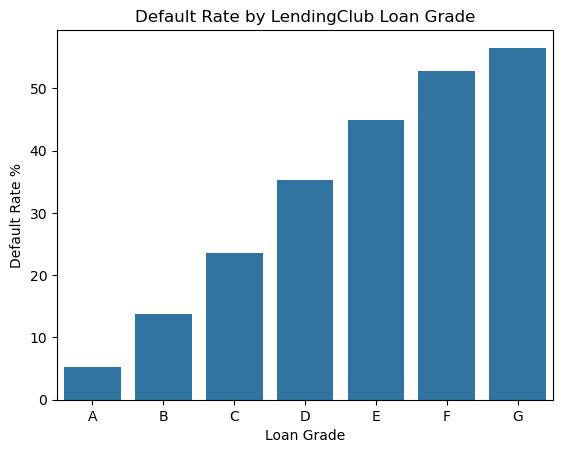

In [17]:
# As we can see above, the default rates are increasing steadily across LendingClub's loan grades, 
# from grade A (lowest risk) to Grade G (highest risk)
# Let's make a bar chart to better visualize the increase in default risk from grades A -> G

sns.barplot(x='grade', y='default_pct', data=grade_default)
plt.title("Default Rate by LendingClub Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate %")

plt.show()

**Key Insight**

The bar chart above demonstrates that default rates increase consistently from Grade A through Grade G, confirming that
LendingClub's internal grading system effectively differentiates borrower risk levels. Lower grades (G, F, E) correspond
to substantially higher observed default rates. 

### Credit Score and Default Risk

In [18]:
# Next, we will analyze default rates by FICO Score to examine how borrower credit quality affects risk

# Create FICO score bands to group borrowers by credit quality using score ranges commonly used in lending
df['fico_band'] = pd.cut(
    df['fico_range_low'],
    bins=[0, 660, 700, 740, 780, 850],
    labels=['<660','660-700','700-740','740-780','780+']
)

# Calculate the default rate within each FICO band
fico_default = df.groupby('fico_band', observed=False)['default'].mean().reset_index()
#Convert to percentage for easier interpretation
fico_default['default_pct'] = fico_default['default'] * 100

fico_default

,fico_band,default,default_pct
0,<660,0.275622,27.562234
1,660-700,0.231937,23.193650
2,700-740,0.151108,15.110806
3,740-780,0.087339,8.733945
4,780+,0.062907,6.290672


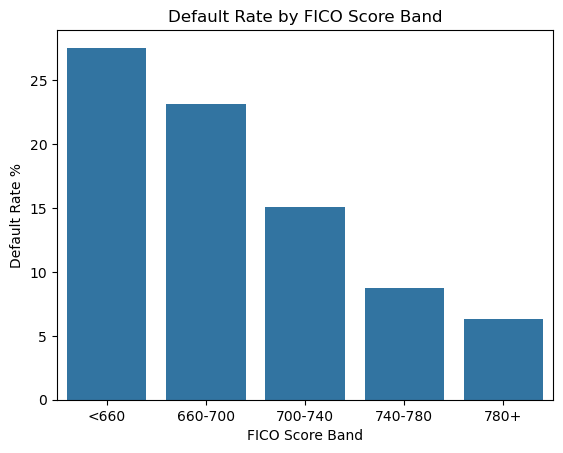

In [19]:
# Now let's create a visualization to better view the relationship between default rates and borrower credit scores

sns.barplot(x='fico_band', y='default_pct', data=fico_default)
plt.title("Default Rate by FICO Score Band")
plt.xlabel("FICO Score Band")
plt.ylabel("Default Rate %")

plt.show()

**Key Insight**

Default rates steadily decline as borrower FICO scores increase, demonstrating a strong inverse relationship between creditworthiness and loan default risk. Borrowers with FICO scores below 660 demonstrate substatially higher default rates compared to borrowers in the prime credit tiers above 740.

### Loan Interest Rate vs Default Risk

In [20]:
# Finally, we will analyze the relationship between interest rate and default risk
# This is an important analysis because it will help to determine whether LendingClub is pricing risk correctly

# We'll start by creating interest rate bands so we can compare default rates across groups of similarly priced loans
# Binning interest rates makes visualizing the relationship easier than looking at thousands of individual loans

df['int_rate_band'] = pd.cut(
    df['int_rate'],
    bins=[5, 10, 15, 20, 25, 30],
    labels=['5-10%', '10-15%', '15-20%', '20-25%', '25-30%']
)

# Calculate the average default rate between each interest rate band
int_rate_default = df.groupby('int_rate_band', observed=False)['default'].mean().reset_index()
# Convert the default rates into percentage form for easier interpretation
int_rate_default['default_pct'] = int_rate_default['default'] * 100

int_rate_default

,int_rate_band,default,default_pct
0,5-10%,0.085252,8.525206
1,10-15%,0.212214,21.221366
2,15-20%,0.379709,37.970906
3,20-25%,0.493794,49.379433
4,25-30%,0.607973,60.797342


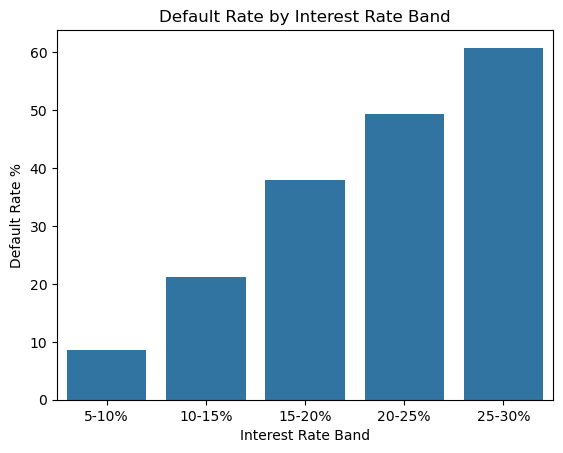

In [21]:
# Create a barplot to better visualize the relationship between interest rate bands and default risk
sns.barplot(x='int_rate_band', y='default_pct', data=int_rate_default)
plt.title("Default Rate by Interest Rate Band")
plt.xlabel("Interest Rate Band")
plt.ylabel("Default Rate %")

plt.show()

**Key Insight**

As demonstrated above, default rates increase sharply across higher interest rate bands. Loans priced between 25-30% exhibit default rates exceeding 60%, while loans priced below 10% default less than 10% of the time. This pattern suggests that LendingClub generally prices loans effectively in accordance with borrower risk, with higher interest rates applied to substantially riskier borrowers.


# From exploratory data analysis to predictive modeling

The analyses above examined several borrower and loan characteristics to understand how they relate to loan default risk. Key variables analyzed included borrower income, borrower debt-to-income ratio, loan amount, loan grade, borrower credit score (FICO), and interest rates. 

Several clear patterns emerged:
- Borrowers with **higher debt-to-income ratios** tend to exhibit higher default risk
- **Loan grades assigned by LendingClub** correspond strongly with observed default rates, with risk increasing steadily from Grade A to Grade G
- **FICO score bands show a strong inverse relationship with default risk**, with lower credit scores associated with substantially higher default rates
- **Higher interest rate loans exhibit significantly higher default rates**, suggesting that LendingClub generally prices loans according to borrower risk
- **Borrower income also appears related to repayment performance**, with lower-income borrowers exhibiting higher default rates on average

While these exploratory visualizations help reveal relationships between individual variables and loan outcomes, credit risk models typically consider **multiple borrower characteristics simultaneously** when estimating default risk.

## Next step: Building a Default Prediction Model

To move from descriptive analysis to predictive modeling, we will build a **logistic regression model** to estimate the probability that a loan will default.

Logisitic regression is widely used in credit risk modeling because it estimates the probability of a binary outcome, such as whether a borrower will default or successfully repay a loan. By incorporating multiple borrower characteristics into a single model, we can better understand how these variables jointly contribute to default risk. 

In the following section, we will:
1. Select relevant borrower and loan characteristics identified during exploratory analysis
2. Split the dataset into training and testing samples
3. Train a logistic regression model to predict loan default
4. Evaluate the model's performance and examine which variables are most strongly associated with default risk

This model provides a simplified illustration of how financial institutions use borrower data to estimate **probability of default (PD)** when evaluating credit risk.

### Variable Selection for the Default Prediction Model

Based on the exploratory analysis, several borrower and loan characteristics appear related to default risk. These variables will be used as input features for the logistic regression model.

The selected features include:
- 'loan_amt' - loan size
- 'annual_inc' - borrower income
- 'dti' - debt-to-income ratio
- 'fico_range_low' - borrower credit score
- 'int_rat' - loan interest rate

Although loan amount **did not** appear strongly predictive in isolation during the exploratory analysis, it is included in the model because loan size relative to borrower income and leverage (dti) may influence repayment capacity when considered alongside other variables. 

And while LendingClub loan grade **did** show a strong relationship with default risk, it is excluded from our predictive model because it represents LendingClub's own internal risk classification. If it were included, our model would therefore be learning partially through LendingClub's own risk model, rather than examining the underlying borrower characteristics that contribute to credit risk.

In [22]:
# Select predictor variables for the model

features = [
    'loan_amnt',
    'annual_inc',
    'dti',
    'fico_range_low',
    'int_rate'
]

# Create feature matrix (X) and target variables (Y)
X = df[features]
y = df['default']

# Verify the data
X.head()

,loan_amnt,annual_inc,dti,fico_range_low,int_rate
0,3600.0,55000.0,5.91,675.0,13.99
1,24700.0,65000.0,16.06,715.0,11.99
2,20000.0,63000.0,10.78,695.0,10.78
4,10400.0,104433.0,25.37,695.0,22.45
5,11950.0,34000.0,10.20,690.0,13.44


### Cleaning the Data & Train-Test Split

Before training the logistic regression model, the dataset is cleaned and divided into **training and testing subsets**. This step ensures that the model is evaluated on data it has not seen during training, which helps provide a more reliable estimate of how well the model will generalize to new loan observations.

In this analysis, **80% of the data will be used to train the model**, while the remaining **20% will be reserved for testing**. The training data allows the model to learn relationships between borrower characteristics and default outcomes, while the test data is used to evaluate the model's predictive performance.

In [23]:
# Remove rows with missing values from the training and testing sets
X = X.dropna()

# Keep the target variable aligned with the cleaned feature data
y = y.loc[X.index]

In [27]:
# Splitting the dataset into training and testing subsets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% of the data used for testing
    random_state=42 # ensures reproducible results
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 35203
Testing observations: 8801


As mentioned earlier, the modeling dataset includes only loans with completed outcomes ("Fully Paid" or "Charged Off"). Loans that are still active or in other intermediate statuses were excluded to ensure the model is trained on finalized repayment outcomes.

### Training the Model

In [25]:
# Train a logistic regression model to estimate the probability of loan default

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
# Use the trained model to predict default outcomes on the test dataset

predictions = model.predict(X_test)

predictions[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Evaluating the Model

In [29]:
# Evaluate overall model accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8044540393137144


This means that the model is correctly predicting the outcome about ~80% of the time. However, this could be misleading since most loans are repaid. Let's further evaluate the results by class to compare the model's prediction accuracy for repaid vs defaulted loans.

In [30]:
# Generate classification performance metrics 

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89      7056
           1       0.54      0.09      0.16      1745

    accuracy                           0.80      8801
   macro avg       0.68      0.54      0.52      8801
weighted avg       0.76      0.80      0.74      8801



#### First, let's define the metrics that the classification report reveals:

**Precision** answers: When the model predicts a default, how often is it correct?

Formula: Precision = True Positives / (True Positives + False Positives)

    High precision -> few false alarms
    Low precision -> many good borrowers flagged as risky

**Recall** answers: Out of all actual defaults, how many did the model catch?

Formula: Recall = True Positive / (True Positives + False Negatives)

    High recall -> catching most risky borrowers
    Low recall -> many defaults slipping through

**F1 Score** balances precision and recall

Formula: F1 = 2 x ((Precision x Recall) / (Precision + Recall))

    F1 score is useful when class imbalance exists. A low F1 suggests that the model struggles to identify that class well.

#### Interpreting the Results

**Class 0 : Fully Paid Loans**

Precision: **0.81**
Recall: **0.98**

Meaning:

    - When the model predicts repaid, it is correct 81% of the time
    - The model correctly identifies 98% of all repaid loans

This means the model is **very good at identifying safe borrowers**.

**Class 1 : Default Loans**

Precision: **0.54**
Recall: **0.09**

This is the most important part in the context of risk management.

Interpretation:

    - When the model predicts a default, it is correct 54% of the time
    - But it only catches 9% of all defaults
    
So the model is **missing most risky borrowers**. 
This behavior is typical of baseline models trained on imbalanced datasets, where the algorithm tends to favor predicting the majority class.


The classification report provides a deeper look at model performance beyond overall accuracy.

The model performs very well at identifying loans that will be fully repaid, achieving a recall of 0.98 for the non-default class. This indicates that **the vast majority of repaid loans are correctly classified**.

However, performance is significantly weaker for predicting defaults. While **over half of predicted defaults are correct** (precision = 0.54), the model **captures only about 9% of the actual defaults in the test dataset** (recall = 0.09). From a risk management perspective, false negatives (defaults predicted as repaid) are particularly costly because they represent loans that appear safe according to the model, but ultimately result in financial losses for the lender.

This imbalance is largely driven by the dataset containing substantially more fully repaid loans than charged-off loans. As a result, the model tends to favor predicting repayment outcomes. In a real-world credit risk context, improving the detection of high-risk borrowers would likely require techniques such as class weighting, resampling, or additional predictive features.



## Interpreting Logistic Regression Coefficients

This section will answer the most interesting question of our analysis:

**Which borrower characteristics actually drive default risk?**

In [31]:
# First, extract the model coefficients to understand the relationship between borrower characteristics and default risk

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients

,Feature,Coefficient
0,loan_amnt,0.000016
1,annual_inc,-0.000001
2,dti,0.016176
3,fico_range_low,-0.005513
4,int_rate,0.154935


In [33]:
# Next, sort features by coefficient value to see which variables most strongly influence default risk

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
4,int_rate,0.154935
2,dti,0.016176
0,loan_amnt,0.000016
1,annual_inc,-0.000001
3,fico_range_low,-0.005513


**Interpreting the Results:**

Logistic regression coefficients indicate how each variable influences the probability of loan default while holding the other variables constant. Positive coefficients are associated with higher default risk, while negative coefficients are associated with lower default risk. 

Among the variables included in the model, interest rate shows the strongest positive relationship with default probability. Loans with higher interest rates are more likely to default, which is consistent with the fact that lenders typically assign higher interest rates to borrowers perceived as riskier. Debt-to-income ratio also shows a positive relationship with default risk, suggesting that borrowers with higher leverage may face greater difficulty meeting repayment obligations.

Conversely, higher borrower income and higher FICO scores are associated with lower default probability. These variables relfect stronger financial stability and creditworthiness, making repayment more likely.

Loan amount shows only a very small positive coefficient, indicating that loan size alone has a relatively limited influence on default risk compared with borrower credit characteristics.

These results align with common lending practices, where borrower credit quality and debt burden are primary determinants of default risk.

## Predicting Probability of Default (PD)

Logistic regression can be used not only to classify loans as likely to repay or default, but also to estimate the **Probability of default (PD)** for each loan observation. 

In credit risk modeling, predicted probabilities are often more informative than simple binary predictions. Rather than labeling a borrower as either "safe" or "risky", the model can assign a continuous probability of default, which allows lenders to compare borrowers by relative risk.

For example, a loan with a predicted default probability of 0.05 (5%) may be considered relatively low risk, while a loan with a probability of 0.60 (60%) may be considered substantially riskier. These probability estimates are often used in real-world lending to support underwriting decisions, pricing, and portfolio risk management.

In the following step, the trained logistic regression model will be used to generate predicted default probabilities for loans in the test dataset.

In [37]:
# Generate predicted probabilities of default for loans in the test dataset

pd_probs = model.predict_proba(X_test)[:, 1]

# Create a dataframe that compares actual outcomes, predicted outcomes, and predicted probabilities of default for a sample of test loans

pd_results = pd.DataFrame({
    'Actual_Outcome': y_test,
    'Predicted_Outcome': predictions,
    'Predicted_PD': pd_probs
})

# Round probabilities for readability

pd_results['Predicted_PD'] = pd_results['Predicted_PD'].round(3)

# Display the first 15 predictions in the test dataset

pd_results.head(15)

,Actual_Outcome,Predicted_Outcome,Predicted_PD
7025,1,0,0.175
963,0,0,0.068
37732,0,0,0.050
49434,0,0,0.249
5074,0,0,0.073
16697,0,0,0.349
24021,0,0,0.240
29833,0,0,0.422
20842,0,0,0.383
23536,1,0,0.118


In [41]:
# Sort loans by estimated probability of default, showing the 10 loans that the model considers the most risky
# This is similar to the way lenders use PD models to rank loans by risk

pd_results.sort_values(by='Predicted_PD', ascending=False).head(10)

,Actual_Outcome,Predicted_Outcome,Predicted_PD
46531,0,1,0.814
5367,1,1,0.811
41856,1,1,0.800
2668,1,1,0.798
16493,1,1,0.797
37395,1,1,0.794
47829,1,1,0.792
41290,1,1,0.787
48825,0,1,0.783
1855,1,1,0.781


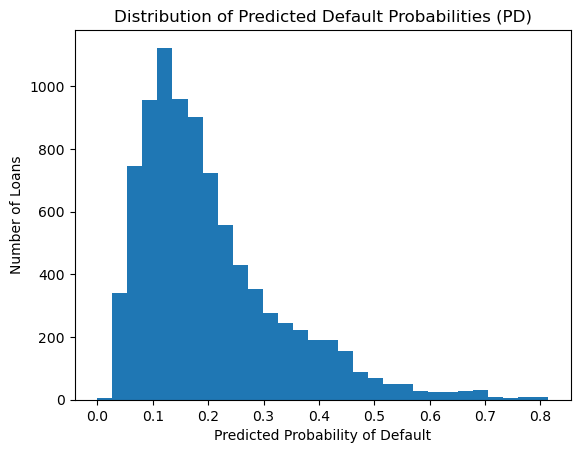

In [42]:
# Visualize the distribution of predicted probabilities of default (PD)

plt.hist(pd_results['Predicted_PD'], bins=30)

plt.title("Distribution of Predicted Default Probabilities (PD)")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Loans")

plt.show()

The distribution of predicted probabilities shows that the majority of the loans in the dataset are assigned relatively low default risk, while a smaller share of loans exhibit moderate probabilities of default, and only a small number represent high-risk loans. This pattern is typical of consumer lending portfolios, where the majority of borrowers ultimately repay their loans.

## Conclusion

This analysis examined how borrower and loan characteristics relate to default risk using historical data from LendingClub. Exploratory analysis revealed several clear relationships between borrower financial characteristics and loan outcomes.

Loans with higher debt-to-income ratios and higher interest rates were associated with higher default rates, while higher FICO scores and borrower income corresponded with lower observed default risk. These relationships were consistent with our expectations based on common lending practices.

A logistic regression model was then used to estimate the probability of default using several borrower and loan-level variables. The model achieved roughly 80% accuracy and performed well at identifying loans that were ultimately repaid, though performance was weaker for detecting defaulted loans due to class imbalance in the dataset. 

Overall, the results highlight the importance of borrower credit quality and financial leverage in predicting loan performance. While this model provides a useful baseline illustration of credit risk modeling, future improvements could include additional feature engineering, class balancing techniques, and more advanced modeling approaches.

**More broadly, this analysis illustrates how borrower characteristics and loan attributes can be used to estimate credit risk and support data-driven lending decisions.**